# Understanding QCMet

This tutorial explains the core concepts and architecture of QCMet benchmarks.

## Running Benchmarks

The easiest way to run a benchmark is using the `__call__` function:

In [ ]:
from qcmet import T1
from qcmet.devices import IdealSimulator

# Create benchmark
experiment = T1()

# Create device
ideal_sim = IdealSimulator()

# Get results
results = experiment(device=ideal_sim, num_shots=1000)

The `__call__` function sequentially executes `generate_circuits()`, `run()` and `analyze()` (and `plot()` if it is implemented). These functions will be described in further detail below.

## The BaseBenchmark Class

All benchmarks in QCMet inherit from `BaseBenchmark`, which provides a consistent interface:

- `generate_circuits()` - Generate the benchmark circuits
- `run(device, num_shots)` - Execute circuits on a device
- `analyze()` - Process results and compute metrics
- `plot()` - Visualize results (if implemented)

## The BaseDevice Class

Devices inherit from `BaseDevice` and implement:

- `run(circuits, num_shots)` - Execute a list of circuits and return measurement counts
- `get_properties()` - Return device properties

This abstraction allows benchmarks to run on any device without modification.

Under the hood, QCMet heavily uses Qiskit's features (in particular, circuits are represented as Qiskit's QuantumCircuit).

## Metric Categories

QCMet organizes benchmarks into categories based on what they measure:

### Qubit Quality Metrics
- **T1**: Relaxation time (energy decay)
- **T2**: Relaxation time (dephasing)
- **Idle Qubit Oscillation Frequency**: Non-Markovian noise induced coherence revivals

### Gate Execution Quality Metrics
- **Clifford RB**: Average gate error rate
- **Interleaved RB**: Specific gate error rate
- **Over/Under Rotation**: Systematic rotation errors
- **Cycle Benchmarking**: Average fidelity of a repeated layer
- **Gate Set Tomography**: Full characterization of process fidelity

### Circuit Execution Quality Metrics
- **Quantum Volume**: Holistic circuit complexity measure
- **Mirrored Circuits**: Target circuit performance benchmark
- **Upper Bound on Variation Distance**: Quantum accreditation protocol

### Well-studied Task Execution Quality Metrics
- **QFT**: Quantum Fourier Transform fidelity
- **VQE**: Energy expectation value reproducibility
- **QScore**: Metric based on using QAOA for a MaxCut problem 
- **Hamiltonian Simulation**: Ability to perform Hamiltonian dynamics


## Example: Exploring the T1 Benchmark

In [2]:
from qcmet import T1
from qcmet.devices import NoisySimulator
import numpy as np

# Create benchmark
t1 = T1(num_idle_gates_per_circ=np.arange(1, 1000, 100))

# Generate circuits
t1.generate_circuits()

# Inspect the experiment data structure
print("Experiment data columns:", t1.experiment_data.columns.tolist())
print("\nFirst few rows:")
print(t1.experiment_data.head())

Experiment data columns: ['hash', 'id', 'circuit']

First few rows:
                               hash                                    id  \
0  010b614c4773c3cc057914f2452e1abd  cef8fd5b-a171-45e8-a7d0-f5d327197331   
1  60f69467bcf27869429777838f863958  05c0eb10-8161-4942-93e6-4c8ea5957cd5   
2  5234934c916137d9c1140bbc0850be78  e2fb6581-90a7-421e-a934-bb4f134b9395   
3  e0580ef9e815af069c70ed84a14429d1  d6b6a2e0-17c9-4037-80b5-f59826ca0201   
4  255ef6a71771ba7f1d2e3c87e6efaa00  2166ce39-64b0-4aea-b773-20d5bf3cb1a2   

                                             circuit  
0  ((Instruction(name='x', num_qubits=1, num_clbi...  
1  ((Instruction(name='x', num_qubits=1, num_clbi...  
2  ((Instruction(name='x', num_qubits=1, num_clbi...  
3  ((Instruction(name='x', num_qubits=1, num_clbi...  
4  ((Instruction(name='x', num_qubits=1, num_clbi...  


In [3]:
# Look at a circuit
print("First circuit:")
print(t1.circuits[0])

First circuit:
        ┌───┐ ░ ┌───┐ ░  ░ ┌─┐
     q: ┤ X ├─░─┤ I ├─░──░─┤M├
        └───┘ ░ └───┘ ░  ░ └╥┘
meas: 1/════════════════════╩═
                            0 


In [4]:
# Run on device
device = NoisySimulator()
t1.run(device, num_shots=1024)

# Check the measurements have been added
print("After running, columns:", t1.experiment_data.columns.tolist())
print("\nSample measurements:")
print(t1.experiment_data['circuit_measurements'].head())

After running, columns: ['hash', 'id', 'circuit', 'circuit_measurements']

Sample measurements:
0     {'0': 1, '1': 1023}
1    {'0': 22, '1': 1002}
2     {'0': 44, '1': 980}
3     {'0': 63, '1': 961}
4     {'0': 73, '1': 951}
Name: circuit_measurements, dtype: object


## The Experiment Data DataFrame

Each benchmark stores its data in a pandas DataFrame with:

- `hash`: Circuit hash for identification
- `id`: Unique circuit ID
- `circuit`: The QuantumCircuit object
- `circuit_measurements`: Measurement counts (added after running)
- Additional benchmark-specific metadata

## Configuration Dictionary

Each benchmark has a `config` dictionary storing its parameters:

In [5]:
print("T1 configuration:")
print(t1.config)

T1 configuration:
{'num_idle_gates_per_circ': array([  1, 101, 201, 301, 401, 501, 601, 701, 801, 901])}


## Saving and Loading

Benchmarks can save their state for later analysis:

Creating dir structure at t1_results/T1_20251222_170315
Results saved to: t1_results


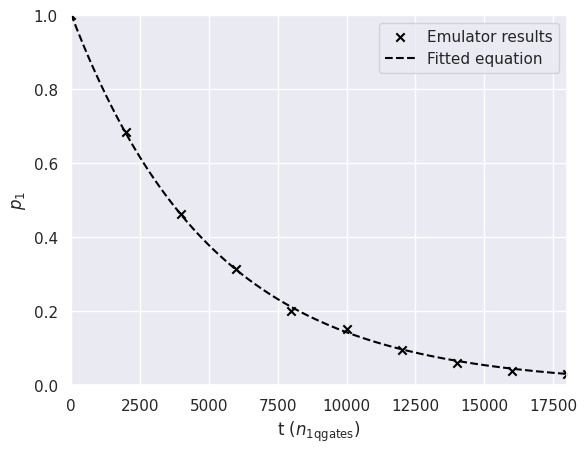

In [9]:
from pathlib import Path

# Create benchmark with save path
t1_saved = T1(
    num_idle_gates_per_circ=np.arange(1, 20000, 2000),
    save_path=Path("./t1_results")
)

# Generate and run
t1_saved.generate_circuits()
t1_saved.run(device, num_shots=1024)

# Analyze and save
results = t1_saved.analyze()
print(f"Results saved to: {t1_saved.file_manager.base_path}")

## Offline Mode

You can generate circuits without a device for later execution:

In [10]:
# Create benchmark with save enabled
t1_offline = T1(
    num_idle_gates_per_circ=np.arange(1, 500, 100),
    save_path=Path("./t1_offline")
)

# Generate circuits
t1_offline.generate_circuits()

# Run without device (saves circuits for later)
t1_offline.run()  # No device specified

print("Circuits saved for offline execution")

Creating dir structure at t1_offline/T1_20251222_170315
Circuits saved for offline execution
